In [2]:
import os
import pandas as pd
import numpy as np
import stylia as st
import matplotlib.pyplot as plt

datapath = "../data"
outpath = "../output"

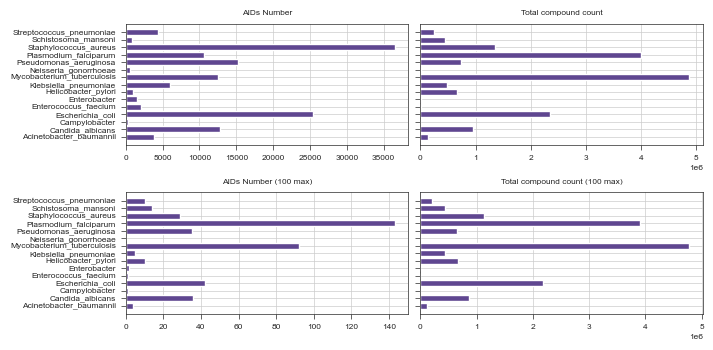

In [50]:
df_plot= pd.read_csv(os.path.join(datapath, "processed", "bioassays_summary","summary.csv"))

fig, axs = st.create_figure(2,2)
ax = axs.next()
ax.barh(df_plot["pathogen"], df_plot["n_bioassays"])
st.label(ax, title = "AIDs Number", xlabel = "", ylabel = "")
ax = axs.next()
ax.barh(df_plot["pathogen"], df_plot["total_cnt"])
ax.tick_params(axis="y", labelleft=False)
st.label(ax, title = "Total compound count", xlabel = "", ylabel = "")
ax = axs.next()
ax.barh(df_plot["pathogen"], df_plot["n_bioassays_100"])
st.label(ax, title = "AIDs Number (100 max)", xlabel = "", ylabel = "")
ax = axs.next()
ax.barh(df_plot["pathogen"], df_plot["total_cnt_100"])
ax.tick_params(axis="y", labelleft=False)
st.label(ax, title = "Total compound count (100 max)", xlabel = "", ylabel = "")
plt.tight_layout()
st.save_figure(os.path.join(outpath,"plots", "00_total_aids.png"))

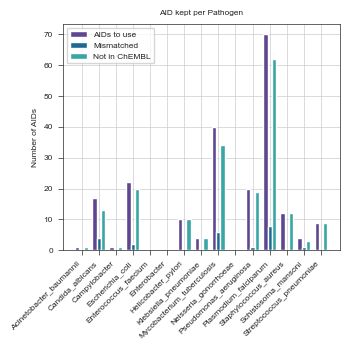

In [15]:
df_plot= pd.read_csv(os.path.join(datapath, "processed", "bioassays_to_keep","summary.csv"))

x = np.arange(len(df_plot["pathogen"]))
width = 0.25
fig,axs=st.create_figure(1,1)
ax=axs.next()
ax.bar(x - width, df_plot["aids_to_use"], width, label="AIDs to use")
ax.bar(x,         df_plot["aids_mismatched"], width, label="Mismatched")
ax.bar(x + width, df_plot["aids_not_in_chembl_keep"], width, label="Not in ChEMBL")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["pathogen"], rotation=45, ha="right")

ax.set_ylabel("Number of AIDs")
ax.set_xlabel("")
ax.set_title("AID kept per Pathogen")
ax.legend()
plt.tight_layout()
st.save_figure(os.path.join(outpath,"plots", "02_aids_to_keep.png"))

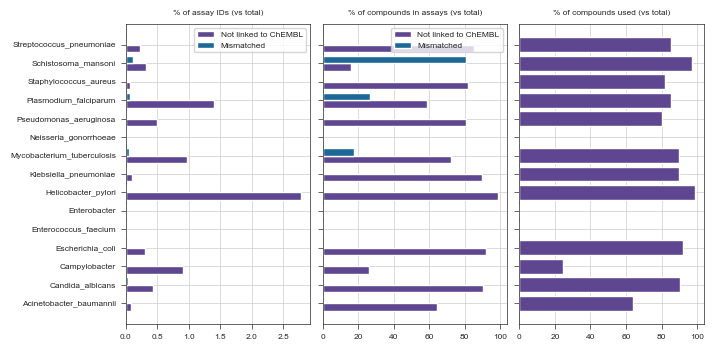

In [16]:
df= pd.read_csv(os.path.join(datapath, "processed", "bioassays_to_keep","summary.csv"))
df["difference"] = df["cpd_count_bioassay_aids"] - df["cpd_count_chembl_ids"]

df["pct_aids_not_in_chembl"] = (
    df["aids_not_in_chembl"] / df["bioassay_aids"] * 100
)

df["pct_cpds_not_in_chembl"] = (
    df["cpd_count_not_in_chembl"] / df["cpd_count_bioassay_aids"] * 100
)

df["pct_cpds_not_in_chembl_used"] = (
    df["cpd_count_not_in_chembl_keep"] / df["cpd_count_not_in_chembl"] * 100
)

df["pct_aids_mismatched"] = (
    df["aids_mismatched"] / df["bioassay_aids"] * 100
)

df["pct_cpds_mismatched"] = (
    df["cpd_count_mismatched"] / df["cpd_count_bioassay_aids"] * 100
)

df["pct_cpds_to_use"] = (
    df["cpd_count_to_use"] / df["cpd_count_bioassay_aids"] * 100
)

fig, axs = st.create_figure(1,3)
ax = axs.next()
y = np.arange(len(df))
ax.barh(y-0.2,df["pct_aids_not_in_chembl"], height=0.4, label ="Not linked to ChEMBL")
ax.barh(y+0.2,df["pct_aids_mismatched"], height=0.4, label ="Mismatched")
ax.set_yticks(y)
ax.set_yticklabels(df["pathogen"])
ax.legend()
st.label(ax,title="% of assay IDs (vs total)", xlabel="", ylabel="")

ax = axs.next()
ax.barh(y-0.2,df["pct_cpds_not_in_chembl"], height=0.4, label ="Not linked to ChEMBL")
ax.barh(y+0.2,df["pct_cpds_mismatched"], height=0.4, label ="Mismatched")
ax.set_yticks(y)
ax.set_yticklabels("")
ax.legend()
st.label(ax,title="% of compounds in assays (vs total)", xlabel="", ylabel="")

ax = axs.next()
ax.barh(y,df["pct_cpds_to_use"])
ax.set_yticks(y)
ax.set_yticklabels("")
st.label(ax,title="% of compounds used (vs total)", xlabel="", ylabel="")

plt.tight_layout()
st.save_figure(os.path.join(outpath, "plots", "chembl_pubchem_overview.png"))

In [53]:
df.to_csv(os.path.join(outpath,"results","pubchem_chembl_summary.csv"), index=False)

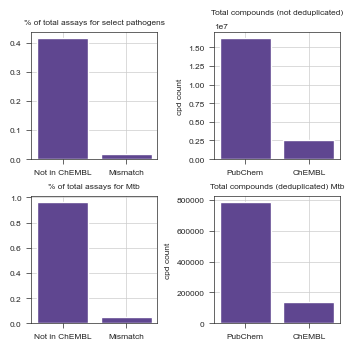

In [17]:
fig, axs = st.create_figure(2,2, width=st.ONE_COLUMN_WIDTH)

ax=axs.next()
ax.bar(
    ["Not in ChEMBL", "Mismatch"],
    [
        df["aids_not_in_chembl"].sum() / df["bioassay_aids"].sum() * 100,
        df["aids_mismatched"].sum() / df["bioassay_aids"].sum() * 100,
    ]
)
st.label(ax,title="% of total assays for select pathogens",  ylabel="",xlabel="" )

ax=axs.next()
ax.bar(
    ["PubChem", "ChEMBL"],
    [
        df["cpd_count_bioassay_aids"].sum(),
        df["cpd_count_chembl_ids"].sum(),
    ]
)
st.label(ax,title="Total compounds (not deduplicated)",  ylabel="cpd count",xlabel="" )

ax=axs.next()
row = df[df["pathogen"] == "Mycobacterium_tuberculosis"].iloc[0]
ax.bar(
    ["Not in ChEMBL", "Mismatch"],
    [
        row["aids_not_in_chembl"] / row["bioassay_aids"] * 100,
        row["aids_mismatched"] / row["bioassay_aids"] * 100,
    ]
)
st.label(ax,title="% of total assays for Mtb",  ylabel="",xlabel="" )

ax = axs.next()
chembl_mtb = pd.read_csv(os.path.join("../tmp/compound_counts.csv"))
pubchem_mtb = pd.read_csv(os.path.join(datapath, "processed", "unique_cids", "unique_cids_mycobacterium_tuberculosis.csv"))
len(pubchem_mtb)
ax.bar(
    ["PubChem", "ChEMBL"],
    [
        len(pubchem_mtb),
        len(chembl_mtb),
    ]
)
st.label(ax,title="Total compounds (deduplicated) Mtb",  ylabel="cpd count",xlabel="" )
plt.tight_layout()

st.save_figure(os.path.join(outpath, "plots", "chembl_pubchem_mtb_overview.png"))

In [33]:
# Compare Compounds deduplicated between ChEMBL and PubChem for pathogens of interest
pubchem_all = pd.read_csv(os.path.join(datapath, "processed", "unique_cids", "unique_cids_all_pathogens.csv"))
chembl_all = pd.read_csv(os.path.join("../tmp/compound_info.csv"))

print(len(pubchem_all),len(set(pubchem_all["cid"].tolist())),len(set(pubchem_all["inchikey"].tolist())),len(set(pubchem_all["smiles"].tolist())))
print(len(chembl_all), len(set(chembl_all["chembl_id"].tolist())), len(set(chembl_all["standard_inchi_key"].tolist())), len(set(chembl_all["canonical_smiles"].tolist())))

1540577 1540577 1538348 1540566
2854815 2854815 2854815 2854654


888445


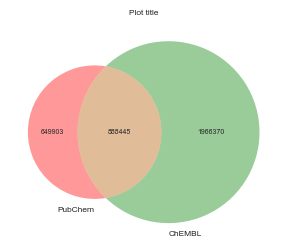

In [43]:
from matplotlib_venn import venn2

#this diagram does plot ALL CHEMBL not only the pathogen related data.

pubchem_inchi = set(pubchem_all["inchikey"].dropna())
chembl_inchi = set(chembl_all["standard_inchi_key"].dropna())
print(len(pubchem_inchi.intersection(chembl_inchi)))
fig, axs =st.create_figure(1,1)
ax=axs.next()
venn2(
    [pubchem_inchi, chembl_inchi],
    set_labels=("PubChem", "ChEMBL"), ax=ax
)
ax.set_title=""

In [46]:
# Compare Compounds deduplicated between ChEMBL and PubChem for MTB
pubchem = pd.read_csv(os.path.join(datapath, "processed", "unique_cids","unique_cids_mycobacterium_tuberculosis.csv"))
chembl = pd.read_csv(os.path.join("../tmp/compound_counts.csv"))

print(len(pubchem),len(set(pubchem["cid"].tolist())),len(set(pubchem["inchikey"].tolist())),len(set(pubchem["smiles"].tolist())))
print(len(chembl), len(set(chembl["compound_chembl_id"].tolist())), len(set(chembl["InChIKey"].tolist())), len(set(chembl["canonical_smiles"].tolist())))

786247 786247 785597 786244
138543 138543 138543 138543


136008


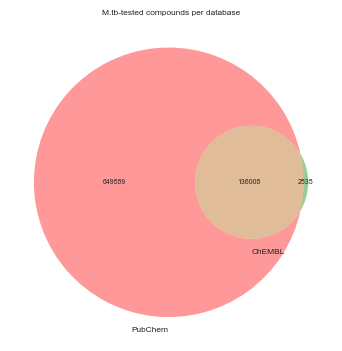

In [50]:
from matplotlib_venn import venn2

pubchem_inchi = set(pubchem["inchikey"].dropna())
chembl_inchi = set(chembl["InChIKey"].dropna())
print(len(pubchem_inchi.intersection(chembl_inchi)))
fig, axs =st.create_figure(1,1)
ax=axs.next()
venn2(
    [pubchem_inchi, chembl_inchi],
    set_labels=("PubChem", "ChEMBL"), ax=ax
)
ax.set_title("M.tb-tested compounds per database")
st.save_figure(os.path.join(outpath, "plots", "mtb_pubchem_chembl_cpds.png"))